# Energy Consumption Regression using Pipelines

This notebook demonstrates professional Data Science best practices:
1.  **Pipelines**: To cleanly chain preprocessing and modeling.
2.  **Cross-Validation**: To reliably estimate model performance on the training set.
3.  **Strict Evaluation**: Using the Test set only at the very end.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Handle warnings
import warnings
warnings.filterwarnings('ignore')

c:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Load Data

In [2]:
df_train = pd.read_csv("train_energy_data.csv")
column_names = df_train.columns

print(f"Training Data Shape: {df_train.shape}")
df_train.head()

Training Data Shape: (1000, 7)


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


## 2. Exploratory Data Analysis (Quick Check)
Before modeling, we check correlations to see if any feature is perfectly correlated with the target (which might explain the 1.0 R2 score).

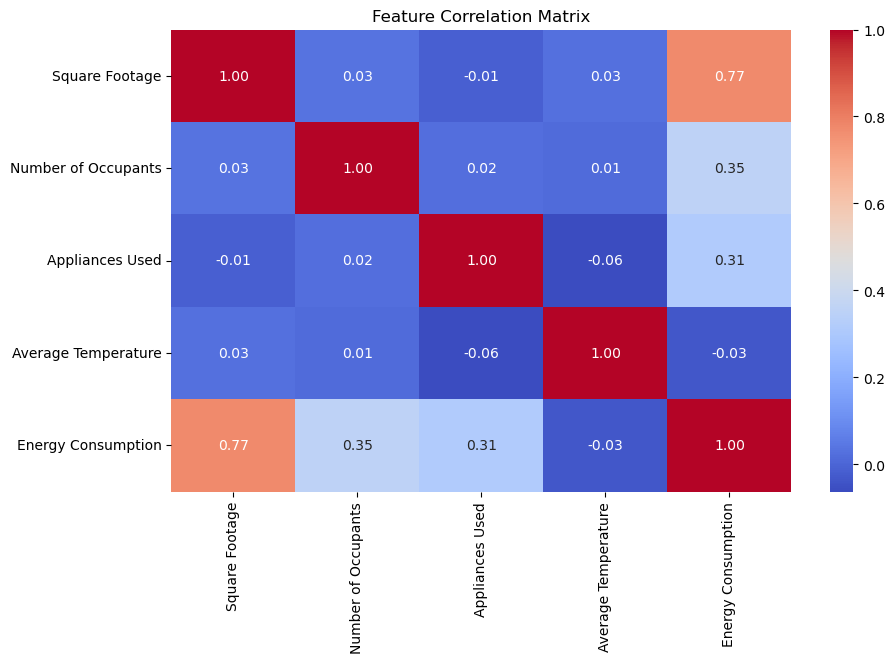

In [3]:
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## 3. Define Preprocessing Pipeline
Instead of manually manually scaling/encoding, we define a recipe.

In [4]:
X = df_train.drop("Energy Consumption", axis=1)
y = df_train["Energy Consumption"]
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

preprocessor

Categorical: ['Building Type', 'Day of Week']
Numerical: ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Square Footage', 'Number of Occupants',
                                  'Appliances Used', 'Average Temperature']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Building Type', 'Day of Week'])])

## 4. Model Selection with Cross-Validation
We will test multiple models. Instead of a single train/val split, we use **5-Fold Cross Validation**.
This splits the training data into 5 chunks, training on 4 and testing on 1, rotating 5 times. It gives a much more stable score.

**NOTE ON METRICS:**
*   **R2 Score:** Higher is better (closer to 1.0).
*   **RMSE (Root Mean Sq Error):** Lower is better. 
    *   *Technical Detail:* Scikit-learn cross_val_score always tries to MAXIMIZE a score. Since RMSE should be MINIMIZED, Scikit-learn provides `neg_root_mean_squared_error` (which is negative). We multiply it by -1 to get the positive RMSE values we are used to.

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

results = []

print("Training and Cross-Validating Models...")
print("-" * 60)

for name, model in models.items():
    my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('model', model)])

    cv_r2 = cross_val_score(my_pipeline, X, y, cv=5, scoring='r2')
    
    # 2. Calculate RMSE (Lower is better)
    # Scikit-learn metrics for CV are always "higher is better" (utility functions).
    # So for error metrics, it returns a negative value.
    # We use 'neg_root_mean_squared_error' and multiply by -1 to get the positive RMSE.
    cv_rmse_neg = cross_val_score(my_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -1 * cv_rmse_neg

    mean_r2 = cv_r2.mean()
    mean_rmse = cv_rmse.mean()
    
    print(f"{name:20} | R2: {mean_r2:.4f} | RMSE: {mean_rmse:.4f}")
    
    results.append({
        "Model": name, 
        "R2_Mean": mean_r2, 
        "RMSE_Mean": mean_rmse
    })

results_df = pd.DataFrame(results).sort_values(by="R2_Mean", ascending=False)
results_df

Training and Cross-Validating Models...
------------------------------------------------------------
Linear Regression    | R2: 1.0000 | RMSE: 0.0138
Decision Tree        | R2: 0.9349 | RMSE: 236.8227
Random Forest        | R2: 0.9812 | RMSE: 127.4114
XGBoost              | R2: 0.9837 | RMSE: 118.1670


,Model,R2_Mean,RMSE_Mean
0,Linear Regression,1.000000,0.013758
3,XGBoost,0.983744,118.166969
2,Random Forest,0.981164,127.411437
1,Decision Tree,0.934852,236.822712


## 5. Final Model Training & Test Set Evaluation
Now that we've compared them, we verify the winner on the **Test Set** (`test_energy_data.csv`).
We will fit the best model on the **entire** training dataset first.

In [6]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models[best_model_name]

print(f"Selected Best Model: {best_model_name}")

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', best_model_obj)])

# Fit on FULL training data (no split needed anymore, we already validated)
final_pipeline.fit(X, y)
df_test = pd.read_csv("test_energy_data.csv")
X_test = df_test.drop("Energy Consumption", axis=1)
y_test = df_test["Energy Consumption"]

y_test_pred = final_pipeline.predict(X_test)

final_r2 = r2_score(y_test, y_test_pred)
final_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

print(f"\nFinal Test Performance ({best_model_name}):")
print(f"R2 Score: {final_r2:.5f}")
print(f"RMSE:     {final_rmse:.5f}")

Selected Best Model: Linear Regression

Final Test Performance (Linear Regression):
R2 Score: 1.00000
RMSE:     0.01420


### Why this is safer?
1. **No Data Leakage**: The scaler is fitted ONLY on the training folds during CV, and ONLY on the training `X` during final fit. It transforms the test set using the train set's statistics.
2. **Simpler Code**: No more `pd.concat` or managing multiple dataframes.
3. **Robustness**: 5-Fold CV ensures the model score isn't a fluke from a lucky random split.